In [1]:
import glob
import pickle

import numpy as np

from experiments.end_to_end.proof_node import ErrorNode, ProofFinishedNode

bestfs_traces = glob.glob('../runs/bestfs-novel-2/*')



In [409]:
from experiments.end_to_end.proof_node import InternalNode


def get_valid_children(node):
    return len([d.dst[0] for d in node.out_edges if
                node.out_edges and not isinstance(d.dst[0], ErrorNode) and not isinstance(d.dst[0], ProofFinishedNode)])
def get_valid_children_2(node):
    # get valid tactics:
    valid_tactics = set()
    seen = set()
    for response in node.out_edges:
        result = response.dst

        for result_node in result:
            # Don't search proved/explored/queued nodes
            if isinstance(result_node,
                          InternalNode) and result_node not in seen:
                seen.add(result_node)
                tac = (response.tactic, response.tac_logprob)
                if tac not in valid_tactics:
                    valid_tactics.add(tac)
                    
    return len(valid_tactics)
    

In [3]:
import tqdm

valid_children = []

for trace in tqdm.tqdm(bestfs_traces):
    try:
        with open(trace, 'rb') as f:
            bestfs = pickle.load(f)
    except:
        print('error loading')
        continue
    if not bestfs:
        print('empty')
        continue
    for node in bestfs.nodes.values():
        if node.out_edges:
            valid_children.append(get_valid_children(node))


100%|██████████| 2000/2000 [06:53<00:00,  4.84it/s]


In [410]:
valid_children_2 = []

for trace in tqdm.tqdm(bestfs_traces):
    try:
        with open(trace, 'rb') as f:
            bestfs = pickle.load(f)
    except:
        print('error loading')
        continue
    if not bestfs:
        print('empty')
        continue
    for node in bestfs.nodes.values():
        if node.out_edges:
            valid_children_2.append(get_valid_children_2(node))


100%|██████████| 2000/2000 [06:51<00:00,  4.86it/s]


<Axes: ylabel='Count'>

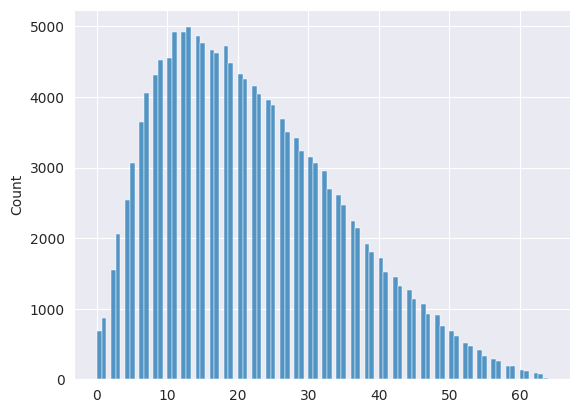

In [4]:
# plot the distribution of valid tactics (no direct error)

import seaborn as sns

sns.histplot(valid_children)


<Axes: ylabel='Count'>

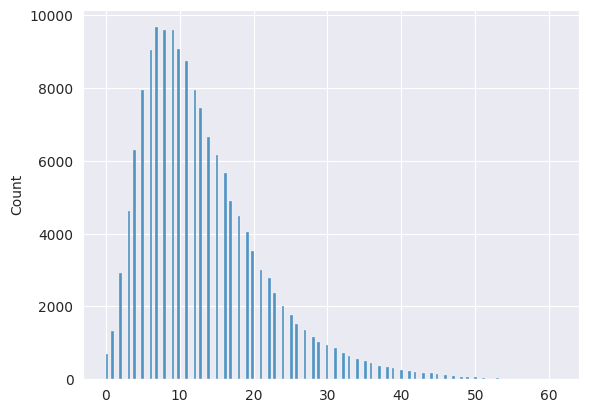

In [411]:
# plot the distribution of valid children (# tactics with a unique node)

sns.histplot(valid_children_2)


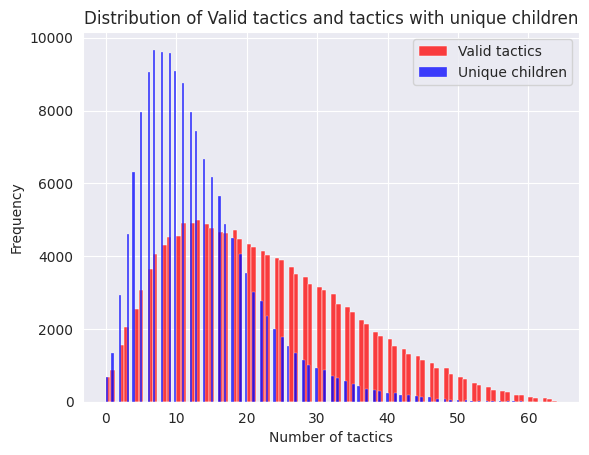

In [421]:
# overlay the two plots

import matplotlib.pyplot as plt
# add title, labels, legend
sns.histplot(valid_children, color='red', label='Valid tactics')
sns.histplot(valid_children_2, color='blue', label='Unique children')
plt.legend()
plt.title('Distribution of Valid tactics and tactics with unique children')
plt.xlabel('Number of tactics')
plt.ylabel('Frequency')
plt.show()


# takeaway: large number of valid tactics, but many of them are redundant (i.e. they lead to the same node)


In [424]:
sum([1 if v > 16 else 0 for v in valid_children_2]) / len(valid_children_2)

0.2667515528351765

In [7]:
import pickle

with open('dpp_error.pk', 'rb') as f:
    dpp_error = pickle.load(f)

from dppy.finite_dpps import FiniteDPP
import torch


In [111]:
(vec_matrix, encs, probs, tactics, state, theorem, temperature) = dpp_error


In [186]:

# get top p tactics, where p is the cumulative probability of the top k tactics, such that the sum of the probabilities of the top k tactics is greater than or equal to p
def top_p(probs, p):
    s = 0
    for i in range(len(probs)):
        s += probs[i]
        if s >= p:
            return i + 1



In [425]:
temperature = 1
scale = 1

start = 0
end = 16
logprobs = [t[1] / temperature for t in tactics]

probs = torch.softmax(torch.tensor(logprobs), dim=0) * scale

sim_matrix_ = torch.cat(encs[start:end], dim=0)

sim_matrix = sim_matrix_ @ sim_matrix_.t()
sim_matrix = sim_matrix.cpu().numpy()

vec_matrix = torch.mul(sim_matrix_.cpu(), probs[start:end].unsqueeze(1)).numpy()
vec_matrix = vec_matrix @ vec_matrix.T

[(i, t[0], probs[i].item()) for i, t in enumerate(tactics[start:end])]

[(0, 'refl', 0.29306602478027344),
 (1, 'simp [t_ih]', 0.13724437355995178),
 (2, 'cases tl', 0.0697539895772934),
 (3,
  'simp [<a>first_order.language.term.constants_to_vars</a>]',
  0.04129168391227722),
 (4,
  'cases <a>first_order.language.term.func</a> ih t_ts',
  0.03563927114009857),
 (5, 'simp', 0.03365802764892578),
 (6,
  'rw [<a>first_order.language.term.constants_to_vars</a>, t_ih]',
  0.02791406214237213),
 (7, 'cases ih', 0.025407293811440468),
 (8,
  'rw <a>first_order.language.term.constants_to_vars</a>',
  0.021796071901917458),
 (9, 'rw t_ih', 0.016997624188661575),
 (10, 'apply t_ih', 0.016237160190939903),
 (11, 'simp [t_ih, t_ih]', 0.015206420794129372),
 (12,
  'rw [<a>first_order.language.term.constants_to_vars</a>]',
  0.012443473562598228),
 (13, 'cases ih : ih', 0.012423446401953697),
 (14, 'simp [<a>first_order.language.term.func</a>]', 0.008225092664361),
 (15, 'unfold constants_to_vars', 0.008045784197747707)]

In [445]:

# DPP = FiniteDPP('likelihood', **{'L': vec_matrix})
DPP = FiniteDPP('likelihood', **{'L': sim_matrix})
DPP.compute_K()


k_sum = sum(DPP.K_eig_vals)
# print(k_sum)
probs = DPP.K_eig_vals[::-1] / k_sum
# print (probs)
k = top_p(probs, 0.95)
print (k)

12


In [446]:
DPP = FiniteDPP('likelihood', **{'L': vec_matrix})
DPP.sample_exact_k_dpp(size=k, mode='KuTa12')  #, rng

filtered = [(i,tactics[start+ i]) for i in sorted(DPP.list_of_samples[0])]
filtered

[(0, ('refl', -2.208911418914795)),
 (1, ('simp [t_ih]', -2.967546224594116)),
 (2, ('cases tl', -3.6443347930908203)),
 (3,
  ('simp [<a>first_order.language.term.constants_to_vars</a>]',
   -4.1686482429504395)),
 (4,
  ('cases <a>first_order.language.term.func</a> ih t_ts', -4.315861225128174)),
 (6,
  ('rw [<a>first_order.language.term.constants_to_vars</a>, t_ih]',
   -4.560178756713867)),
 (7, ('cases ih', -4.65427303314209)),
 (8,
  ('rw <a>first_order.language.term.constants_to_vars</a>',
   -4.807579517364502)),
 (10, ('apply t_ih', -5.102006912231445)),
 (11, ('simp [t_ih, t_ih]', -5.167591571807861)),
 (13, ('cases ih : ih', -5.369723796844482)),
 (15, ('unfold constants_to_vars', -5.804161071777344))]

In [447]:
[(i,t) for i,t in enumerate(tactics[start:end]) if (i,t) not in filtered]

[(5, ('simp', -4.373057842254639)),
 (9, ('rw t_ih', -5.0562357902526855)),
 (12,
  ('rw [<a>first_order.language.term.constants_to_vars</a>]',
   -5.368113040924072)),
 (14, ('simp [<a>first_order.language.term.func</a>]', -5.7821197509765625))]

In [311]:
samples = []
for _ in range(1000):
    DPP = FiniteDPP('likelihood', **{'L': vec_matrix})
    DPP.sample_exact_k_dpp(size=k, mode='KuTa12')  #, rng
    samples.append(DPP.list_of_samples[0])

from collections import Counter

Counter([tactics[i][0] for s in samples for i in sorted(s)])


Counter({'refl': 955,
         'simp [t_ih]': 808,
         'cases tl': 798,
         'cases <a>first_order.language.term.func</a> ih t_ts': 629,
         'cases ih': 528,
         'simp [<a>first_order.language.term.constants_to_vars</a>]': 465,
         'rw [<a>first_order.language.term.constants_to_vars</a>, t_ih]': 463,
         'simp': 354})

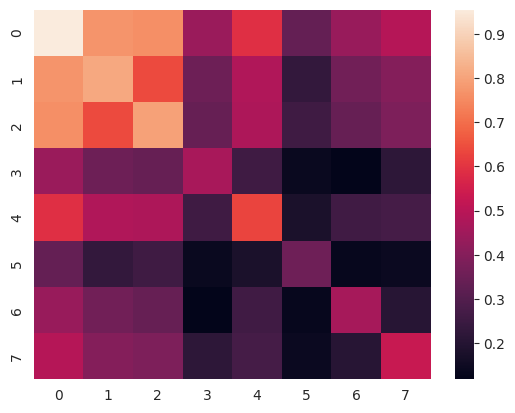

In [313]:

# plot the co-occurences of tactics, pairwise
co_occurences = torch.zeros((end-start,end-start))
for s in samples:
    for i in s:
        for j in s:
            co_occurences[i, j] += 1

co_occurences = co_occurences / len(samples)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(co_occurences)
plt.show()


In [ ]:
# minif2f benchmark code here:  (245 test theorems)
# https://github.com/lean-dojo/LeanDojo/blob/legacy/scripts/generate-benchmark-lean3.ipynb

In [27]:
import glob

bestfs_traces = glob.glob('../runs/bestfs-novel-2/*')
# diversity_traces = glob.glob('../runs/search/diversity-temp=1/2024_07_22/13_33_28/traces/0/*')


# 8 filter
diversity_traces = glob.glob('../runs/search/diversity-search-8-filter/2024_07_26/16_21_14/traces/0/*')

# 16 filter
diversity_traces = glob.glob('../runs/search/diversity-16-filter/traces/*')

# bfs
# diversity_traces = glob.glob('../runs/end_to_end/bfs/2024_06_04/16_30_28/traces/0/*')

In [28]:
names = {d.split('/')[-1] for d in bestfs_traces}
diversity_traces = [d for d in diversity_traces if d.split('/')[-1] in names]
names = {d.split('/')[-1] for d in diversity_traces}
bestfs_traces = [d for d in bestfs_traces if d.split('/')[-1] in names]


In [29]:
len(bestfs_traces)

1448

In [30]:
from tqdm import tqdm
import pickle

successes = []
fails = []
for i in tqdm(range(len(bestfs_traces))):
    try:
        with open(bestfs_traces[i], 'rb') as f:
            bestfs = pickle.load(f)
        with open(diversity_traces[i], 'rb') as f:
            diversity = pickle.load(f)
    except:
        continue

    if bestfs.proof and not diversity.proof:
        successes.append((bestfs, diversity))
    elif not bestfs.proof and diversity.proof:
        fails.append((bestfs, diversity))




100%|██████████| 1448/1448 [04:52<00:00,  4.94it/s]


In [39]:
with open(diversity_traces[1], 'rb') as f:
    diversity_test = pickle.load(f)

ModuleNotFoundError: No module named 'github.GithubRetry'

In [33]:
len(successes)

0

In [35]:
len(fails)

0

In [43]:
import github

In [48]:
github

<module 'github' from '/home/sean/Documents/venvs/bait/lib/python3.10/site-packages/github/__init__.py'>

In [ ]:
# [s[0].proof for s in successes]

In [ ]:
# [s[1].proof for s in fails]

In [ ]:
best_trace, diverse_trace = successes[0]


In [ ]:
best_trace.tree.data['augmented_state'] == diverse_trace.tree.data['augmented_state']

In [ ]:
set([t.tactic for t in best_trace.tree.out_edges])  # == 

In [ ]:
set([t.tactic for t in diverse_trace.tree.out_edges])

In [ ]:
best_trace.proof

In [ ]:
len([d for d in best_trace.tree.out_edges if not isinstance(d.dst[0], ErrorNode)])


In [ ]:
len([d for d in diverse_trace.tree.out_edges if not isinstance(d.dst[0], ErrorNode)]), len(
    [d for d in best_trace.tree.out_edges if not isinstance(d.dst[0], ErrorNode)])



In [ ]:
[(d, d.dst[0]) for d in diverse_trace.tree.out_edges]

In [ ]:
from experiments.end_to_end.proof_node import ErrorNode

node1 = [d.dst for d in best_trace.tree.out_edges if d.tactic == best_trace.proof[0]][0][0]

In [ ]:
node2 = [d.dst for d in node1.out_edges if d.tactic == best_trace.proof[1]]
node2[0][0]

In [ ]:
diverse1 = [d.dst[0] for d in diverse_trace.tree.out_edges if d.dst[0] == node1][0]


In [ ]:
diverse2 = [d.dst for d in diverse1.out_edges if d.dst[0] == node2[0][0]]

In [ ]:
diverse2

In [ ]:
best_trace

In [ ]:
diverse_trace

In [ ]:
# bestfs success 0, missed out on state by removing simp tactic with relevant lemma (depth 1)
# success 1, missed out on proof at first level by removing rw tactic with relevant lemma (depth 0)
# success 2, missed out on proof at first level by removing rw tactic with relevant lemma (depth 0). Other tactics with same lemma, however they resulted in an error.
# success 3, missed tactic but had lemma (simp_rw<- vs simp_rw, timed out)
# success 4, 

In [107]:
# test matrices for DPP

# try all ones
# test_matrix = torch.ones((16,16)).numpy()
#  ~ 1


# try identity
# test_matrix = torch.eye(16).numpy()
# = 8


# create 16 vectors, then get the cosine similarity of each pair. Create them such that there are 4 groups of 4, where each group has a high similarity

test_matrix = torch.zeros((16, 16))
for i in range(4):
    for j in range(4):
        test_matrix[i + 4, j + 4] = 0.9
        test_matrix[i + 8, j + 8] = 0.9
        test_matrix[i + 12, j + 12] = 0.8

for i in range(16):
    test_matrix[i, i] = 1

test_matrix = test_matrix.numpy()
test_matrix

array([[1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.9, 0.9, 0.9, 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.9, 1. , 0.9, 0.9, 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.9, 0.9, 1. , 0.9, 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.9, 0.9, 0.9, 1. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0.9, 0.9, 0.9, 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.9, 1. , 0.9, 0.9, 0. ,
        0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.

In [108]:




# DPP = FiniteDPP('likelihood', **{'L': vec_matrix})
DPP = FiniteDPP('likelihood', **{'L': test_matrix})
DPP.compute_K()

k_sum = sum(DPP.K_eig_vals)
print(k_sum)

5.392649173736572


In [110]:
# get percentage of variance explained by each eigenvector
DPP.K_eig_vals[::-1] / k_sum

array([0.1459828 , 0.1459828 , 0.14329271, 0.09271881, 0.09271881,
       0.09271881, 0.09271881, 0.03090629, 0.03090626, 0.03090625,
       0.01685797, 0.01685797, 0.01685796, 0.01685796, 0.01685791,
       0.01685791], dtype=float32)

In [36]:
test_matrix

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,